# 🏠 House Prices — Análisis de Componentes Principales (PCA)
## Machine Learning III · Análisis de componentes

---

Este notebook aplica PCA para reducir la dimensionalidad del dataset de precios de casas,  
conservando la máxima varianza posible en 30 componentes.

| Paso | Descripción |
|------|-------------|
| 1️⃣ | Carga y exploración inicial del dataset |
| 2️⃣ | Limpieza — imputación (mediana/moda) y codificación OHE |
| 3️⃣ | Normalización con `StandardScaler` |
| 4️⃣ | Aplicación de PCA con 30 componentes |
| 5️⃣ | Visualización — barras de varianza + línea acumulada |
| 6️⃣ | Evaluación e interpretación de la varianza explicada |

> **Dataset:** `dataset.csv` — 1 460 registros · 81 columnas  
> **Objetivo:** reducir a 30 componentes principales y evaluar la varianza explicada  
> **Ruta:** `/workspace/dataset.csv`


---
## 0. Importación de librerías


In [27]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13})

# ── Configuración centralizada ────────────────────────────────────────────
# Modifica INPUT_PATH aquí para reutilizar el notebook en otro entorno.
INPUT_PATH   = os.environ.get("DATASET_PATH", "workspace/dataset.csv")
N_COMPONENTS = int(os.environ.get("PCA_N_COMPONENTS", 30))
# También se pueden sobreescribir con variables de entorno:
#   export DATASET_PATH=/ruta/alternativa/dataset.csv
#   export PCA_N_COMPONENTS=50

# ── Ruta absoluta resuelta — útil para depuración en otros entornos ───────
INPUT_PATH_ABS = os.path.abspath(INPUT_PATH)

print("✅ Librerías cargadas correctamente.")
print(f"📂 INPUT_PATH (configurado): {INPUT_PATH}")
print(f"📂 INPUT_PATH (absoluta):    {INPUT_PATH_ABS}")
print(f"   Existe en disco:          {os.path.exists(INPUT_PATH_ABS)}")
print(f"🔢 N_COMPONENTS:             {N_COMPONENTS}")


✅ Librerías cargadas correctamente.
📂 INPUT_PATH (configurado): workspace/dataset.csv
📂 INPUT_PATH (absoluta):    c:\Users\macdu\Downloads\Proyectos-Unir-IA\Proyectos_Unir\Proyectos_ML\ejercicios_mod_3\reto 2\workspace\dataset.csv
   Existe en disco:          True
🔢 N_COMPONENTS:             30


---
## 1. Carga y Exploración Inicial

### 1.1 Carga del dataset


In [28]:
if not os.path.exists(INPUT_PATH):
    raise FileNotFoundError(
        f"\n❌ No se encontró: {INPUT_PATH}\n"
        "   Coloca dataset.csv en /workspace/ antes de ejecutar."
    )

df = pd.read_csv(INPUT_PATH)

# ── Copia del DataFrame original (antes de cualquier transformación) ──────
# Permite comparar el efecto de la limpieza en cualquier momento posterior
# sin necesidad de recargar el CSV.
df_raw = df.copy()

print(f"📐 Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"   df_raw guardado — copia inmutable del CSV original")


📐 Dimensiones: 1460 filas × 81 columnas
   df_raw guardado — copia inmutable del CSV original


### 1.2 Información general (`df.info()`)

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

### 1.3 Primeras filas

In [30]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### 1.4 Análisis de valores faltantes

In [31]:
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
nulos_df = (pd.DataFrame({"Nulos": nulos, "Porcentaje (%)": nulos_pct})
              .query("Nulos > 0")
              .sort_values("Nulos", ascending=False))

print(f"🔍 Columnas con valores faltantes: {len(nulos_df)} / {len(df.columns)}")
print(f"   Total de celdas nulas: {nulos.sum():,}\n")
print(nulos_df.to_string())


🔍 Columnas con valores faltantes: 19 / 81
   Total de celdas nulas: 7,829

              Nulos  Porcentaje (%)
PoolQC         1453           99.52
MiscFeature    1406           96.30
Alley          1369           93.77
Fence          1179           80.75
MasVnrType      872           59.73
FireplaceQu     690           47.26
LotFrontage     259           17.74
GarageType       81            5.55
GarageYrBlt      81            5.55
GarageFinish     81            5.55
GarageQual       81            5.55
GarageCond       81            5.55
BsmtExposure     38            2.60
BsmtFinType2     38            2.60
BsmtQual         37            2.53
BsmtCond         37            2.53
BsmtFinType1     37            2.53
MasVnrArea        8            0.55
Electrical        1            0.07


### 1.5 Mapa de calor de valores faltantes

El heatmap permite detectar **patrones de ausencia** entre variables:  
si varias columnas presentan nulos en las mismas filas puede indicar  
que la información falta de forma sistemática (e.g. ausencia de garaje → varias columnas de garaje sin dato a la vez).


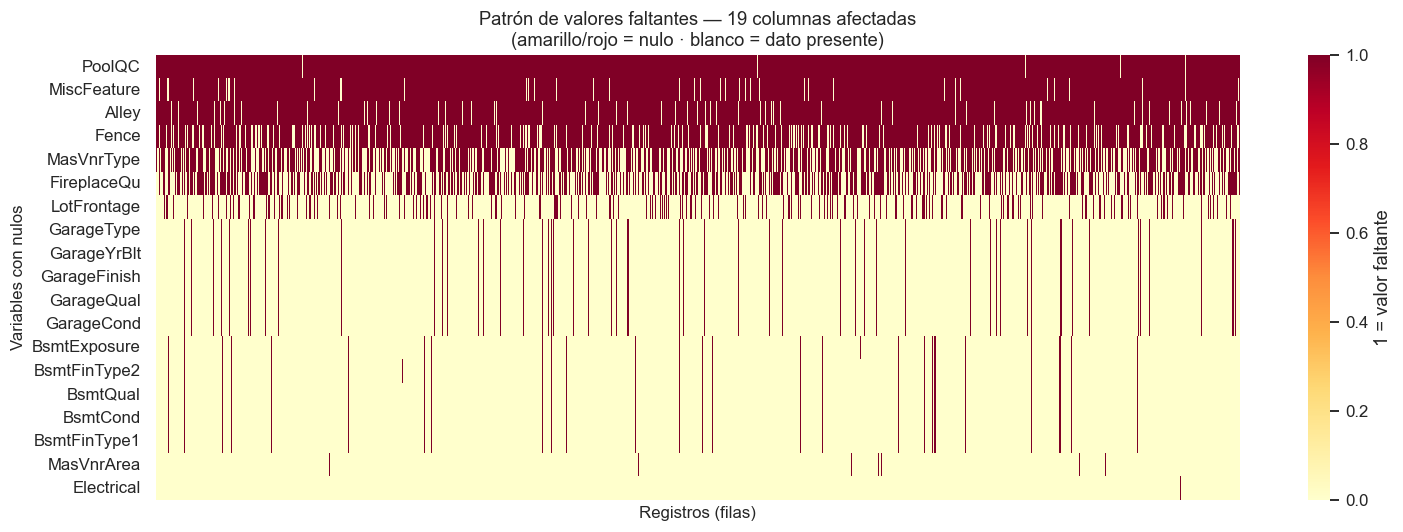

🔍 Correlación de ausencia entre columnas (valor > 0.8 = patrón sistemático):
  · GarageType           ↔ GarageYrBlt           r = 1.000
  · GarageType           ↔ GarageFinish          r = 1.000
  · GarageType           ↔ GarageQual            r = 1.000
  · GarageType           ↔ GarageCond            r = 1.000
  · GarageYrBlt          ↔ GarageFinish          r = 1.000
  · GarageYrBlt          ↔ GarageQual            r = 1.000
  · GarageYrBlt          ↔ GarageCond            r = 1.000
  · GarageFinish         ↔ GarageQual            r = 1.000
  · GarageFinish         ↔ GarageCond            r = 1.000
  · GarageQual           ↔ GarageCond            r = 1.000


In [32]:
# Solo columnas con al menos un nulo, ordenadas por número de nulos
cols_con_nulos = nulos_df.index.tolist()

fig, ax = plt.subplots(figsize=(14, 5))
# Mapa binario: 1 = nulo (amarillo), 0 = presente (morado)
sns.heatmap(
    df[cols_con_nulos].isnull().astype(int).T,
    cmap="YlOrRd",
    cbar_kws={"label": "1 = valor faltante"},
    yticklabels=True,
    xticklabels=False,   # 1 460 filas — omitir etiquetas del eje X
    ax=ax
)
ax.set_xlabel("Registros (filas)", fontsize=11)
ax.set_ylabel("Variables con nulos", fontsize=11)
ax.set_title(
    f"Patrón de valores faltantes — {len(cols_con_nulos)} columnas afectadas\n"
    "(amarillo/rojo = nulo · blanco = dato presente)",
    fontsize=12
)
plt.tight_layout()
plt.show()

# Detectar columnas que suelen aparecer juntas en los nulos
print("🔍 Correlación de ausencia entre columnas (valor > 0.8 = patrón sistemático):")
missing_corr = df[cols_con_nulos].isnull().astype(int).corr()
pairs = [
    (c1, c2, missing_corr.loc[c1, c2])
    for i, c1 in enumerate(cols_con_nulos)
    for c2 in cols_con_nulos[i+1:]
    if missing_corr.loc[c1, c2] > 0.8
]
if pairs:
    for c1, c2, r in sorted(pairs, key=lambda x: -x[2])[:10]:
        print(f"  · {c1:20s} ↔ {c2:20s}  r = {r:.3f}")
else:
    print("  No se detectan patrones sistemáticos de ausencia conjunta.")


---
## 2. Limpieza de Datos

### 2.1 Imputación de valores faltantes

- **Columnas numéricas** → mediana (robusta frente a outliers)
- **Columnas categóricas** → moda (valor más frecuente)


In [33]:
# Separar columnas por tipo
cols_num = df.select_dtypes(include=["number"]).columns.tolist()
cols_cat = df.select_dtypes(include=["object", "str"]).columns.tolist()

print(f"📊 Columnas numéricas:   {len(cols_num)}")
print(f"📊 Columnas categóricas: {len(cols_cat)}")

# ── Imputación numérica: mediana ──────────────────────────────────────────
for col in cols_num:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# ── Imputación categórica: moda ───────────────────────────────────────────
for col in cols_cat:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print(f"\n✅ Imputación completada.")
print(f"   Valores nulos residuales: {df.isnull().sum().sum()}")

# ── Comparativa df_raw vs df imputado ─────────────────────────────────────
cols_con_nulos_orig = df_raw.columns[df_raw.isnull().any()].tolist()
print(f"\n📊 Efecto de la imputación (columnas que tenían nulos):\n")
print(f"  {'Columna':<22}  {'Nulos antes':>12}  {'Nulos después':>14}  "
      f"{'Mediana/Moda usada':>20}")
print("  " + "─" * 75)
for col in cols_con_nulos_orig:
    n_antes = df_raw[col].isnull().sum()
    n_desp  = df[col].isnull().sum()
    if col in cols_num:
        val_str = f"{df_raw[col].median():,.2f} (mediana)"
    else:
        val_str = f"{df_raw[col].mode()[0]} (moda)"
    print(f"  {col:<22}  {n_antes:>12}  {n_desp:>14}  {val_str:>20}")


📊 Columnas numéricas:   38
📊 Columnas categóricas: 43

✅ Imputación completada.
   Valores nulos residuales: 0

📊 Efecto de la imputación (columnas que tenían nulos):

  Columna                  Nulos antes   Nulos después    Mediana/Moda usada
  ───────────────────────────────────────────────────────────────────────────
  LotFrontage                      259               0       69.00 (mediana)
  Alley                           1369               0           Grvl (moda)
  MasVnrType                       872               0        BrkFace (moda)
  MasVnrArea                         8               0        0.00 (mediana)
  BsmtQual                          37               0             TA (moda)
  BsmtCond                          37               0             TA (moda)
  BsmtExposure                      38               0             No (moda)
  BsmtFinType1                      37               0            Unf (moda)
  BsmtFinType2                      38               0       

### 2.2 Codificación de variables categóricas con `pd.get_dummies()`

`pd.get_dummies` convierte cada variable categórica en columnas binarias (0/1).  
Se usa `drop_first=True` para evitar multicolinealidad (trampa de variable dummy).


In [34]:
shape_antes = df.shape

df_encoded = pd.get_dummies(df, columns=cols_cat, drop_first=True, dtype=int)

# ── Verificación: no deben quedar columnas de tipo objeto ─────────────────
# Si quedase alguna, StandardScaler y PCA fallarían con un TypeError.
cols_obj_restantes = df_encoded.select_dtypes(include=["object","str"]).columns.tolist()
if cols_obj_restantes:
    raise TypeError(
        f"⚠️  Quedan {len(cols_obj_restantes)} columnas de tipo objeto tras OHE: "
        f"{cols_obj_restantes}. Revisa la codificación."
    )

print(f"📐 Shape antes de OHE:   {shape_antes}")
print(f"📐 Shape después de OHE: {df_encoded.shape}")
print(f"   Nuevas columnas creadas: {df_encoded.shape[1] - shape_antes[1]}")
print(f"\n✅ Codificación completada. Total features: {df_encoded.shape[1]}")
print(f"✅ Verificación de tipos: 0 columnas de tipo objeto — listo para escalar.")


📐 Shape antes de OHE:   (1460, 81)
📐 Shape después de OHE: (1460, 246)
   Nuevas columnas creadas: 165

✅ Codificación completada. Total features: 246
✅ Verificación de tipos: 0 columnas de tipo objeto — listo para escalar.


---
## 3. Normalización con `StandardScaler`

PCA maximiza la varianza de las proyecciones lineales. Sin normalización, variables  
con rangos grandes (p.ej. `SalePrice` en miles) dominarían los componentes frente  
a variables con rangos pequeños, sesgando los resultados.

`StandardScaler` centra cada columna en media=0 y escala a σ=1.


In [35]:
# ── Resumen antes del escalado (muestra 5 columnas representativas) ──────
COLS_MUESTRA = [c for c in ["SalePrice","GrLivArea","LotArea",
                             "OverallQual","YearBuilt"]
                if c in df_encoded.columns][:5]

print("📊 Efecto de StandardScaler — comparativa antes / después:\n")
print(f"  {'Columna':<22}  {'Media (antes)':>16}  {'Std (antes)':>13}  "
      f"{'Media (después)':>17}  {'Std (después)':>14}")
print("  " + "─" * 90)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

# X_scaled_df: solo se crea para inspección — se usa numpy para el resto.
# En datasets muy grandes conviene operar directamente con X_scaled (array)
# para evitar duplicar memoria; aquí el DataFrame se descarta tras la tabla.
_X_scaled_df = pd.DataFrame(X_scaled, columns=df_encoded.columns)
for col in COLS_MUESTRA:
    print(f"  {col:<22}  {df_encoded[col].mean():>16,.2f}  "
          f"{df_encoded[col].std():>13,.2f}  "
          f"{_X_scaled_df[col].mean():>17.4f}  "
          f"{_X_scaled_df[col].std():>14.4f}")
del _X_scaled_df   # liberar memoria — el resto del pipeline usa X_scaled

print(f"\n  ✅ StandardScaler aplicado a {X_scaled.shape[1]} columnas.")
print(f"     Media global:  {X_scaled.mean():.6f}  (≈ 0)")
print(f"     Std global:    {X_scaled.std():.6f}   (≈ 1)")
print()
print("  ℹ️  Las columnas con rangos muy distintos (p.ej. SalePrice en miles")
print("     vs OverallQual en escala 1-10) quedan en la misma unidad σ=1,")
print("     evitando que PCA les asigne peso desproporcionado.")


📊 Efecto de StandardScaler — comparativa antes / después:

  Columna                    Media (antes)    Std (antes)    Media (después)   Std (después)
  ──────────────────────────────────────────────────────────────────────────────────────────
  SalePrice                     180,921.20      79,442.50             0.0000          1.0003
  GrLivArea                       1,515.46         525.48            -0.0000          1.0003
  LotArea                        10,516.83       9,981.26            -0.0000          1.0003
  OverallQual                         6.10           1.38             0.0000          1.0003
  YearBuilt                       1,971.27          30.20             0.0000          1.0003

  ✅ StandardScaler aplicado a 246 columnas.
     Media global:  0.000000  (≈ 0)
     Std global:    1.000000   (≈ 1)

  ℹ️  Las columnas con rangos muy distintos (p.ej. SalePrice en miles
     vs OverallQual en escala 1-10) quedan en la misma unidad σ=1,
     evitando que PCA les asigne p

---
## 4. Aplicación del PCA

Aplicamos PCA con `n_components=30` para reducir la dimensionalidad del dataset  
a 30 componentes principales.


In [36]:
# ── svd_solver='full': determinista, sin random_state ────────────────────
# Se fija explícitamente para documentar la elección y evitar que versiones
# futuras de scikit-learn cambien el solver ('auto' puede elegir 'randomized'
# en datasets grandes, introduciendo no-determinismo).
#
# ── Nota: n_components como fracción de varianza (extensión opcional) ────
# PCA admite pasar n_components como float ∈ (0, 1) para retener ese
# porcentaje de varianza automáticamente:
#   PCA(n_components=0.80) → selecciona los k componentes que sumen ≥ 80%
# En este proyecto se usa n_components=30 por requisito del enunciado.
# El análisis del umbral 80% en la sección 6 conecta directamente con
# lo que PCA(n_components=0.80) calcularía internamente.
pca = PCA(n_components=N_COMPONENTS, svd_solver="full")
X_pca = pca.fit_transform(X_scaled)

print(f"✅ PCA aplicado con {N_COMPONENTS} componentes.")
print(f"   Shape original:  {X_scaled.shape}")
print(f"   Shape reducido:  {X_pca.shape}")
print(f"   Reducción:       {X_scaled.shape[1]} → {X_pca.shape[1]} dimensiones")
print(f"   svd_solver:      {pca.svd_solver!r} (determinista, sin random_state)")
print()
print("  ℹ️  Extensión opcional: PCA(n_components=0.80) seleccionaría")
print(f"     automáticamente los componentes que sumen ≥ 80% de varianza,")
print(f"     equivalente al umbral analizado en la sección 6.")

# ── Flag para el cálculo del umbral 80% (puede ser costoso en datasets grandes)
COMPUTE_IDX80 = True   # False → omite el PCA completo adicional


✅ PCA aplicado con 30 componentes.
   Shape original:  (1460, 246)
   Shape reducido:  (1460, 30)
   Reducción:       246 → 30 dimensiones
   svd_solver:      'full' (determinista, sin random_state)

  ℹ️  Extensión opcional: PCA(n_components=0.80) seleccionaría
     automáticamente los componentes que sumen ≥ 80% de varianza,
     equivalente al umbral analizado en la sección 6.


---
## 5. Visualización de la Varianza Explicada

Gráfico combinado:
- **Barras** (azul): varianza explicada individualmente por cada componente
- **Línea** (naranja): varianza acumulada conforme se añaden componentes


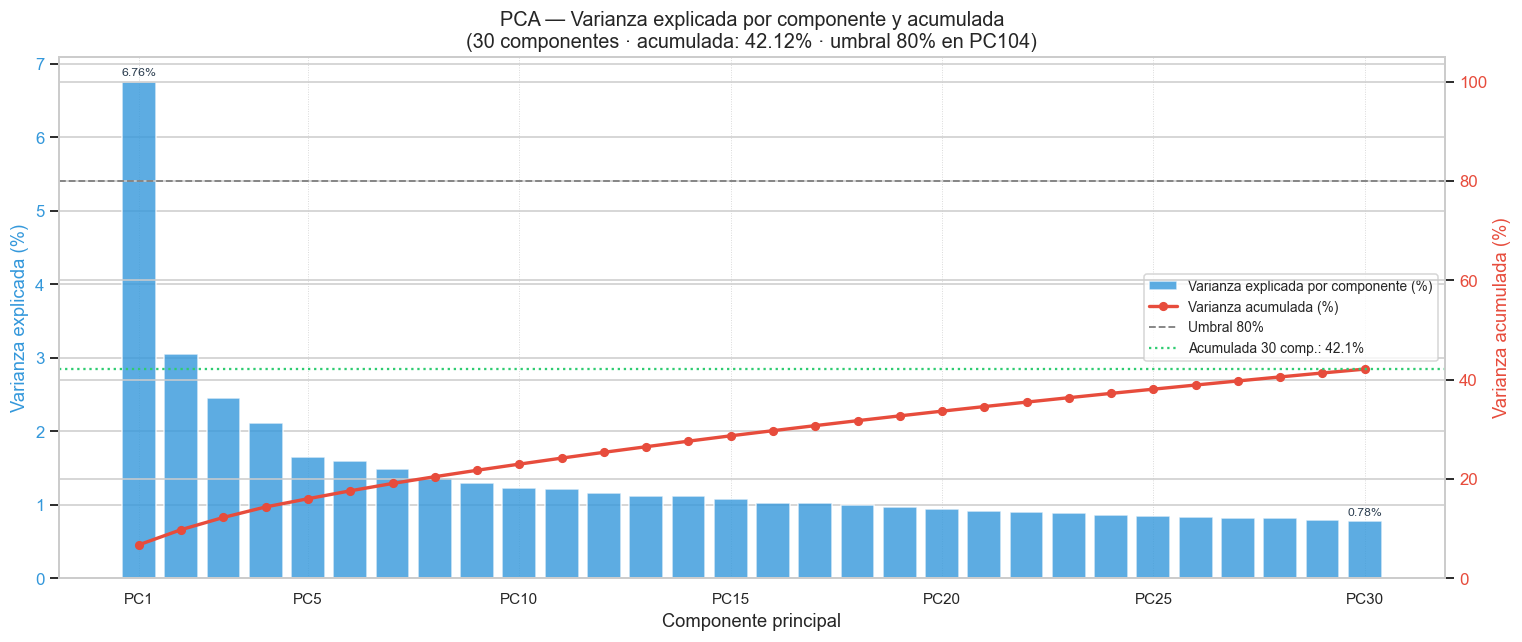

In [37]:
var_exp     = pca.explained_variance_ratio_
var_acum    = np.cumsum(var_exp)
componentes = np.arange(1, N_COMPONENTS + 1)

# ── Calcular idx_80 aquí una sola vez (evita recalcular PCA completo dos veces)
if COMPUTE_IDX80:
    _pca_full      = PCA(svd_solver="full").fit(X_scaled)
    _var_acum_full = np.cumsum(_pca_full.explained_variance_ratio_)
    idx_80 = next((i+1 for i, v in enumerate(_var_acum_full) if v >= 0.80), None)
else:
    idx_80 = None   # omitido para mayor velocidad

fig, ax1 = plt.subplots(figsize=(14, 6))

# ── Barras: varianza individual ───────────────────────────────────────────
bars = ax1.bar(componentes, var_exp * 100,
               color="#3498db", alpha=0.80, edgecolor="white",
               label="Varianza explicada por componente (%)")
ax1.set_xlabel("Componente principal", fontsize=12)
ax1.set_ylabel("Varianza explicada (%)", fontsize=12, color="#3498db")
ax1.tick_params(axis="y", labelcolor="#3498db")

# ── Cuadrícula ligera en eje X para facilitar la lectura ─────────────────
ax1.set_axisbelow(True)
ax1.xaxis.grid(True, linestyle=":", linewidth=0.6, color="#cccccc", alpha=0.8)

# ── Eje X: ticks cada 5 componentes ──────────────────────────────────────
tick_step      = 5
tick_positions = [c for c in componentes if c % tick_step == 0 or c == 1]
ax1.set_xticks(tick_positions)
ax1.set_xticklabels([f"PC{c}" for c in tick_positions], fontsize=10)

# Etiquetar barra 1 y última
for idx in [0, len(componentes) - 1]:
    ax1.text(componentes[idx], var_exp[idx] * 100 + 0.05,
             f"{var_exp[idx]*100:.2f}%", ha="center", va="bottom",
             fontsize=8, color="#2c3e50")

# ── Línea: varianza acumulada ─────────────────────────────────────────────
ax2 = ax1.twinx()
ax2.plot(componentes, var_acum * 100,
         color="#e74c3c", marker="o", markersize=5,
         linewidth=2.2, label="Varianza acumulada (%)")
ax2.set_ylabel("Varianza acumulada (%)", fontsize=12, color="#e74c3c")
ax2.tick_params(axis="y", labelcolor="#e74c3c")
ax2.set_ylim(0, 105)

# Línea umbral 80%
ax2.axhline(80, color="gray", linestyle="--", linewidth=1.2,
            label="Umbral 80%")
ax2.axhline(var_acum[-1] * 100, color="#2ecc71", linestyle=":",
            linewidth=1.5,
            label=f"Acumulada {N_COMPONENTS} comp.: {var_acum[-1]*100:.1f}%")

# ── Marcador del componente en el que se alcanza el 80% ──────────────────
if idx_80 is not None and idx_80 <= N_COMPONENTS:
    # El umbral cae dentro del rango graficado
    y_at_80 = var_acum[idx_80 - 1] * 100
    ax2.scatter([idx_80], [y_at_80], color="#8e44ad", s=100,
                zorder=6, label=f"PC{idx_80} → 80% acumulado")
    ax2.annotate(f"PC{idx_80}\n({y_at_80:.1f}%)",
                 xy=(idx_80, y_at_80),
                 xytext=(idx_80 + 1.5, y_at_80 - 8),
                 fontsize=8, color="#8e44ad",
                 arrowprops=dict(arrowstyle="->", color="#8e44ad", lw=1.2))
elif idx_80 is not None:
    # El umbral cae fuera del rango graficado — anotar en el título
    pass  # se informa en el texto de la sección 6

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="center right", fontsize=9)

idx80_txt = (f" · umbral 80% en PC{idx_80}" if idx_80 else "")
ax1.set_title(
    f"PCA — Varianza explicada por componente y acumulada\n"
    f"({N_COMPONENTS} componentes · acumulada: {var_acum[-1]*100:.2f}%"
    f"{idx80_txt})",
    fontsize=13
)
plt.tight_layout()
plt.show()


---
## 6. Evaluación de la Varianza Explicada


In [38]:
print("📊 Varianza explicada por cada componente:\n")
print(f"  {'Componente':>12}  {'Var. individual (%)':>20}  "
      f"{'Var. acumulada (%)':>20}")
print("  " + "─" * 58)
for i, (ind, acu) in enumerate(zip(var_exp, var_acum), start=1):
    bar = "█" * int(ind * 200)
    print(f"  PC{i:<10}  {ind*100:>19.4f}%  {acu*100:>19.4f}%  {bar}")

print()
print("─" * 60)
varianza_acumulada_30 = var_acum[-1] * 100
diferencia            = 80 - varianza_acumulada_30

print(f"\n📐 Varianza acumulada por los {N_COMPONENTS} primeros componentes:")
print(f"   {varianza_acumulada_30:.4f} %")
print()

if varianza_acumulada_30 >= 80:
    print("✅ La varianza acumulada es ≥ 80%.")
    print("   La reducción de dimensionalidad ha sido efectiva:")
    print(f"   {varianza_acumulada_30:.1f}% de la información original queda")
    print(f"   representada en {N_COMPONENTS} componentes.")
elif diferencia > 20:
    print(f"⚠️  La varianza acumulada ({varianza_acumulada_30:.2f}%) es "
          f"SIGNIFICATIVAMENTE inferior al 80%")
    print(f"   (diferencia de {diferencia:.1f} puntos porcentuales).")
    print()
    print("   Esto indica que 30 componentes capturan menos de la mitad")
    print("   de la varianza total del dataset original, lo cual es")
    print("   esperable en datasets con muchas variables poco correladas")
    print("   (tras OHE este dataset tiene 246 columnas).")
    print()
    print("   ✅ No obstante, el enunciado de este proyecto no requiere")
    print(f"      aumentar el número de componentes más allá de {N_COMPONENTS}.")
else:
    print(f"⚠️  La varianza acumulada ({varianza_acumulada_30:.2f}%) es")
    print(f"   inferior al 80% (diferencia de {diferencia:.1f} p.p.).")
    print("   Para este proyecto esto es aceptable según el enunciado.")

# ── Componente en el que se superaría el 80% (ya calculado en celda 5) ───
print()
if idx_80 is not None:
    print(f"📐 Para superar el umbral del 80% se necesitarían {idx_80} componentes.")
    print(f"   Con {N_COMPONENTS} componentes se retiene el "
          f"{varianza_acumulada_30:.1f}% de la varianza total.")
    if idx_80 <= N_COMPONENTS:
        print(f"   ✅ El umbral cae dentro del rango graficado (PC{idx_80}) "
              "y está marcado en el gráfico anterior.")
    else:
        print(f"   ℹ️  El umbral (PC{idx_80}) supera los {N_COMPONENTS} "
              "componentes graficados — no aparece en el gráfico.")
elif not COMPUTE_IDX80:
    print("ℹ️  Cálculo del umbral 80% desactivado (COMPUTE_IDX80=False).")
    print("   Activa el flag en la celda 4 para obtener este dato.")


📊 Varianza explicada por cada componente:

    Componente   Var. individual (%)    Var. acumulada (%)
  ──────────────────────────────────────────────────────────
  PC1                        6.7568%               6.7568%  █████████████
  PC2                        3.0505%               9.8073%  ██████
  PC3                        2.4581%              12.2654%  ████
  PC4                        2.1181%              14.3835%  ████
  PC5                        1.6504%              16.0339%  ███
  PC6                        1.5903%              17.6243%  ███
  PC7                        1.4815%              19.1058%  ██
  PC8                        1.3589%              20.4647%  ██
  PC9                        1.2980%              21.7627%  ██
  PC10                       1.2351%              22.9977%  ██
  PC11                       1.2109%              24.2086%  ██
  PC12                       1.1668%              25.3754%  ██
  PC13                       1.1245%              26.4999%  